# ScribeCheck — Handwritten Text Evaluation System

**Author:** Shivanshu Ade
**Applied Deep Learning, Semester Project, Spring 2026**  

---

This notebook runs the complete ScribeCheck pipeline:

1. Environment setup
2. Dataset loading and exploration
3. Model loading
4. Preprocessing comparison (basic vs enhanced)
5. OCR evaluation — CER & WER (50 and 200 sample sets)
6. Hybrid similarity scoring
7. Cascade failure analysis
8. Weight sensitivity analysis
9. Difficulty-stratified evaluation
10. Save results
11. Launch Gradio interface

---
## 1. Environment Setup

In [2]:
import sys, os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from jiwer import cer, wer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)

if not os.path.exists(os.path.join(PROJECT_ROOT, 'src')):
    import types
    src_module = types.ModuleType('src')
    src_module.__path__ = [PROJECT_ROOT]
    sys.modules['src'] = src_module

RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Python: {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')
print('Environment ready.')

Python: 3.10.19
PyTorch: 2.5.1
Device: mps
Environment ready.


---
## 2. Load Dataset & Model

In [3]:
print('Loading IAM dataset...')
full_dataset = load_dataset('Teklia/IAM-line', split='train')
full_dataset = full_dataset.shuffle(seed=42)

NUM_TEST_FULL = 200
NUM_TEST_INITIAL = 50

test_data = full_dataset.select(range(NUM_TEST_FULL))
test_data_initial = full_dataset.select(range(NUM_TEST_INITIAL))

print(f'Total dataset: {len(full_dataset)}')
print(f'Initial test set: {NUM_TEST_INITIAL} samples')
print(f'Expanded test set: {NUM_TEST_FULL} samples')

Loading IAM dataset...
Total dataset: 6482
Initial test set: 50 samples
Expanded test set: 200 samples


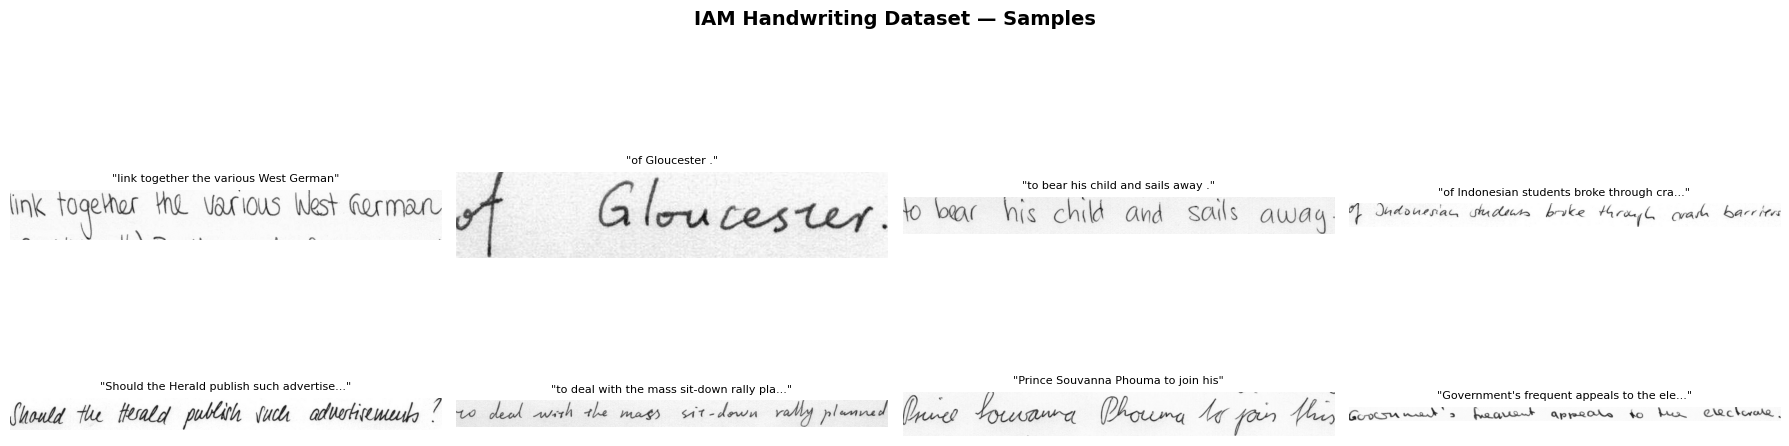

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('IAM Handwriting Dataset — Samples', fontsize=14, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    s = test_data[idx]
    ax.imshow(s['image'], cmap='gray')
    lbl = s['text']
    ax.set_title(f'"{lbl[:40]}..."' if len(lbl) > 40 else f'"{lbl}"', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

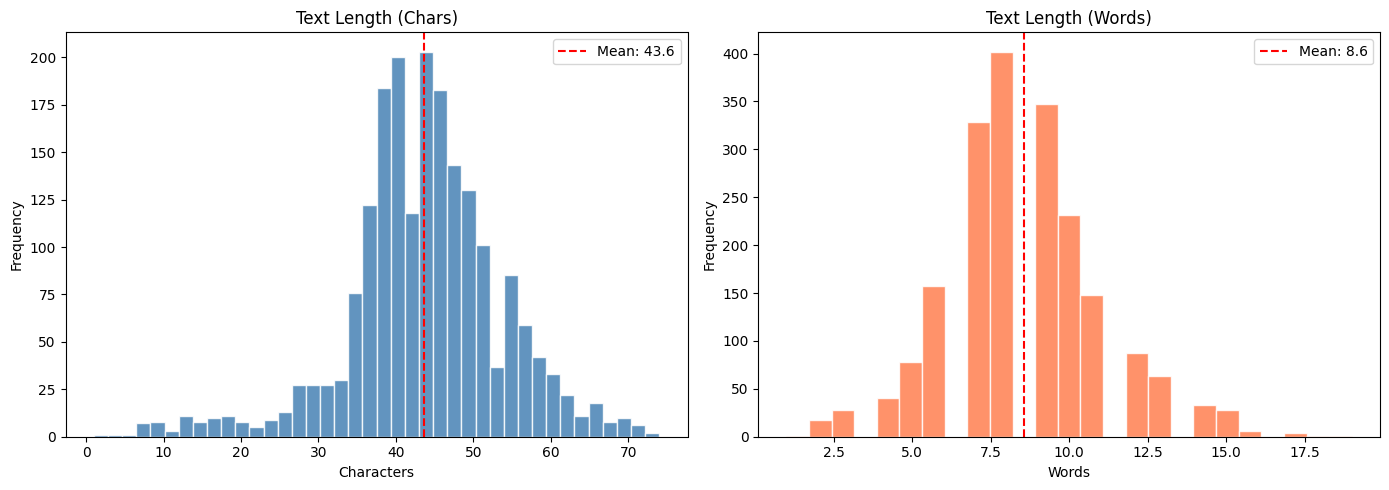

In [5]:
text_lengths = [len(full_dataset[i]['text']) for i in range(min(2000, len(full_dataset)))]
word_counts  = [len(full_dataset[i]['text'].split()) for i in range(min(2000, len(full_dataset)))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(text_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(text_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(text_lengths):.1f}')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Frequency'); axes[0].set_title('Text Length (Chars)'); axes[0].legend()
axes[1].hist(word_counts, bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Mean: {np.mean(word_counts):.1f}')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Frequency'); axes[1].set_title('Text Length (Words)'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'text_length_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [6]:
MODEL_NAME = 'microsoft/trocr-base-handwritten'
print(f'Loading {MODEL_NAME}...')
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print(f'Model loaded on {device} | {sum(p.numel() for p in model.parameters()):,} parameters')

Loading microsoft/trocr-base-handwritten...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on mps | 333,921,792 parameters


---
## 3. Preprocessing Comparison

**Basic pipeline:** Grayscale → Denoise → Otsu binarization → Deskew  
**Enhanced pipeline:** Grayscale → CLAHE contrast enhancement → Denoise → Adaptive binarization → Deskew

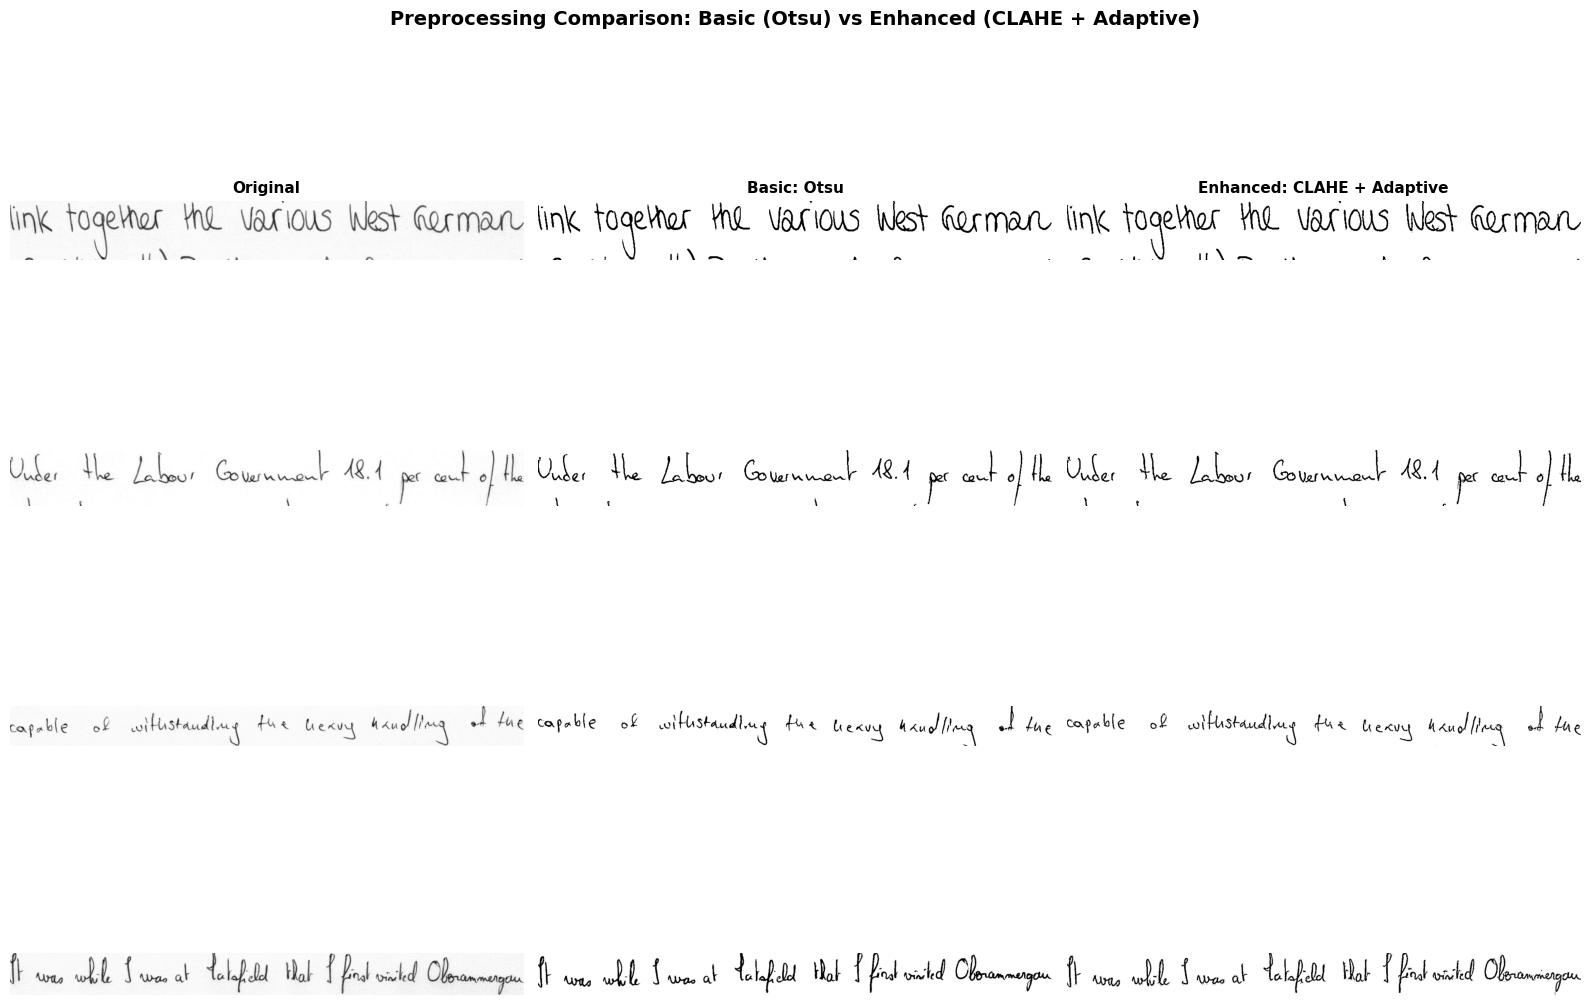

In [7]:
from src.preprocessing import preprocess_comparison, assess_image_quality, pil_to_cv2

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
fig.suptitle('Preprocessing Comparison: Basic (Otsu) vs Enhanced (CLAHE + Adaptive)', fontsize=14, fontweight='bold')
col_titles = ['Original', 'Basic: Otsu', 'Enhanced: CLAHE + Adaptive']

for row in range(4):
    sample = test_data[row * 10]
    cv2_img = pil_to_cv2(sample['image'])
    comparison = preprocess_comparison(cv2_img)
    for col, (key, title) in enumerate(zip(['original', 'basic_preprocessed', 'enhanced_preprocessed'], col_titles)):
        axes[row, col].imshow(comparison[key], cmap='gray')
        if row == 0:
            axes[row, col].set_title(title, fontsize=11, fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'preprocessing_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. OCR Evaluation — CER & WER

**Published baseline:** `trocr-base-handwritten` on full IAM: ~4.4% CER

In [8]:
model.eval()
all_predictions, all_references = [], []

print(f'Running inference on {NUM_TEST_FULL} samples...')
for i in tqdm(range(NUM_TEST_FULL)):
    sample = test_data[i]
    image = sample['image'].convert('RGB')
    pv = processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pv, max_length=128)
    all_predictions.append(processor.batch_decode(ids, skip_special_tokens=True)[0])
    all_references.append(sample['text'])

# Split for comparison
predictions_initial = all_predictions[:NUM_TEST_INITIAL]
references_initial = all_references[:NUM_TEST_INITIAL]

print('Inference complete.')

Running inference on 200 samples...


100%|██████████| 200/200 [01:56<00:00,  1.71it/s]

Inference complete.


In [9]:
from src.evaluation import evaluate_ocr_batch

ocr_initial = evaluate_ocr_batch(predictions_initial, references_initial)
ocr_full = evaluate_ocr_batch(all_predictions, all_references)

cer_initial = [r['cer'] for r in ocr_initial['per_sample']]
wer_initial = [r['wer'] for r in ocr_initial['per_sample']]
cer_full = [r['cer'] for r in ocr_full['per_sample']]
wer_full = [r['wer'] for r in ocr_full['per_sample']]

print('=' * 70)
print('OCR EVALUATION: INITIAL vs EXPANDED')
print('=' * 70)
print(f'{"Metric":<20} {"Initial (50 samples)":>22} {"Expanded (200 samples)":>22}')
print('-' * 70)
print(f'{"Mean CER":<20} {ocr_initial["mean_cer"]:.4f} ({ocr_initial["mean_cer"]*100:.2f}%) {ocr_full["mean_cer"]:.4f} ({ocr_full["mean_cer"]*100:.2f}%)')
print(f'{"Mean WER":<20} {ocr_initial["mean_wer"]:.4f} ({ocr_initial["mean_wer"]*100:.2f}%) {ocr_full["mean_wer"]:.4f} ({ocr_full["mean_wer"]*100:.2f}%)')
print(f'{"Samples":<20} {NUM_TEST_INITIAL:>22} {NUM_TEST_FULL:>22}')
print(f'{"Perfect (CER=0)":<20} {sum(1 for c in cer_initial if c==0):>22} {sum(1 for c in cer_full if c==0):>22}')
print(f'{"Baseline":<20} {"~4.4% CER":>22} {"~4.4% CER":>22}')

OCR EVALUATION: INITIAL vs EXPANDED
Metric                 Initial (50 samples) Expanded (200 samples)
----------------------------------------------------------------------
Mean CER             0.0072 (0.72%) 0.0070 (0.70%)
Mean WER             0.0244 (2.44%) 0.0249 (2.49%)
Samples                                  50                    200
Perfect (CER=0)                          43                    175
Baseline                          ~4.4% CER              ~4.4% CER


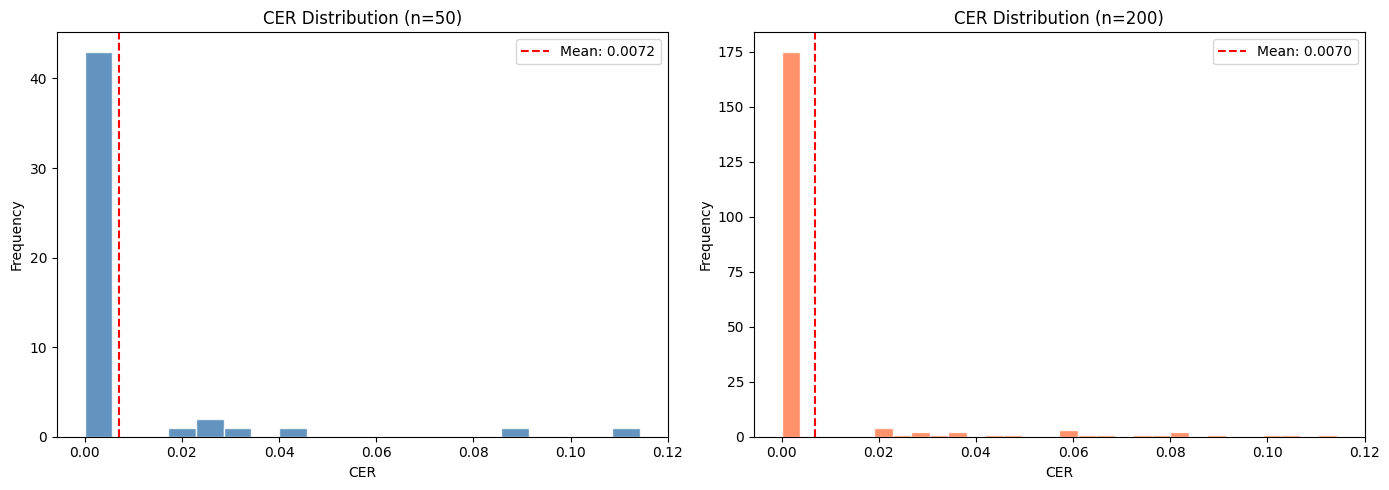

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cer_initial, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(cer_initial), color='red', linestyle='--', label=f'Mean: {np.mean(cer_initial):.4f}')
axes[0].set_xlabel('CER'); axes[0].set_ylabel('Frequency')
axes[0].set_title(f'CER Distribution (n={NUM_TEST_INITIAL})'); axes[0].legend()
axes[1].hist(cer_full, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(cer_full), color='red', linestyle='--', label=f'Mean: {np.mean(cer_full):.4f}')
axes[1].set_xlabel('CER'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'CER Distribution (n={NUM_TEST_FULL})'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

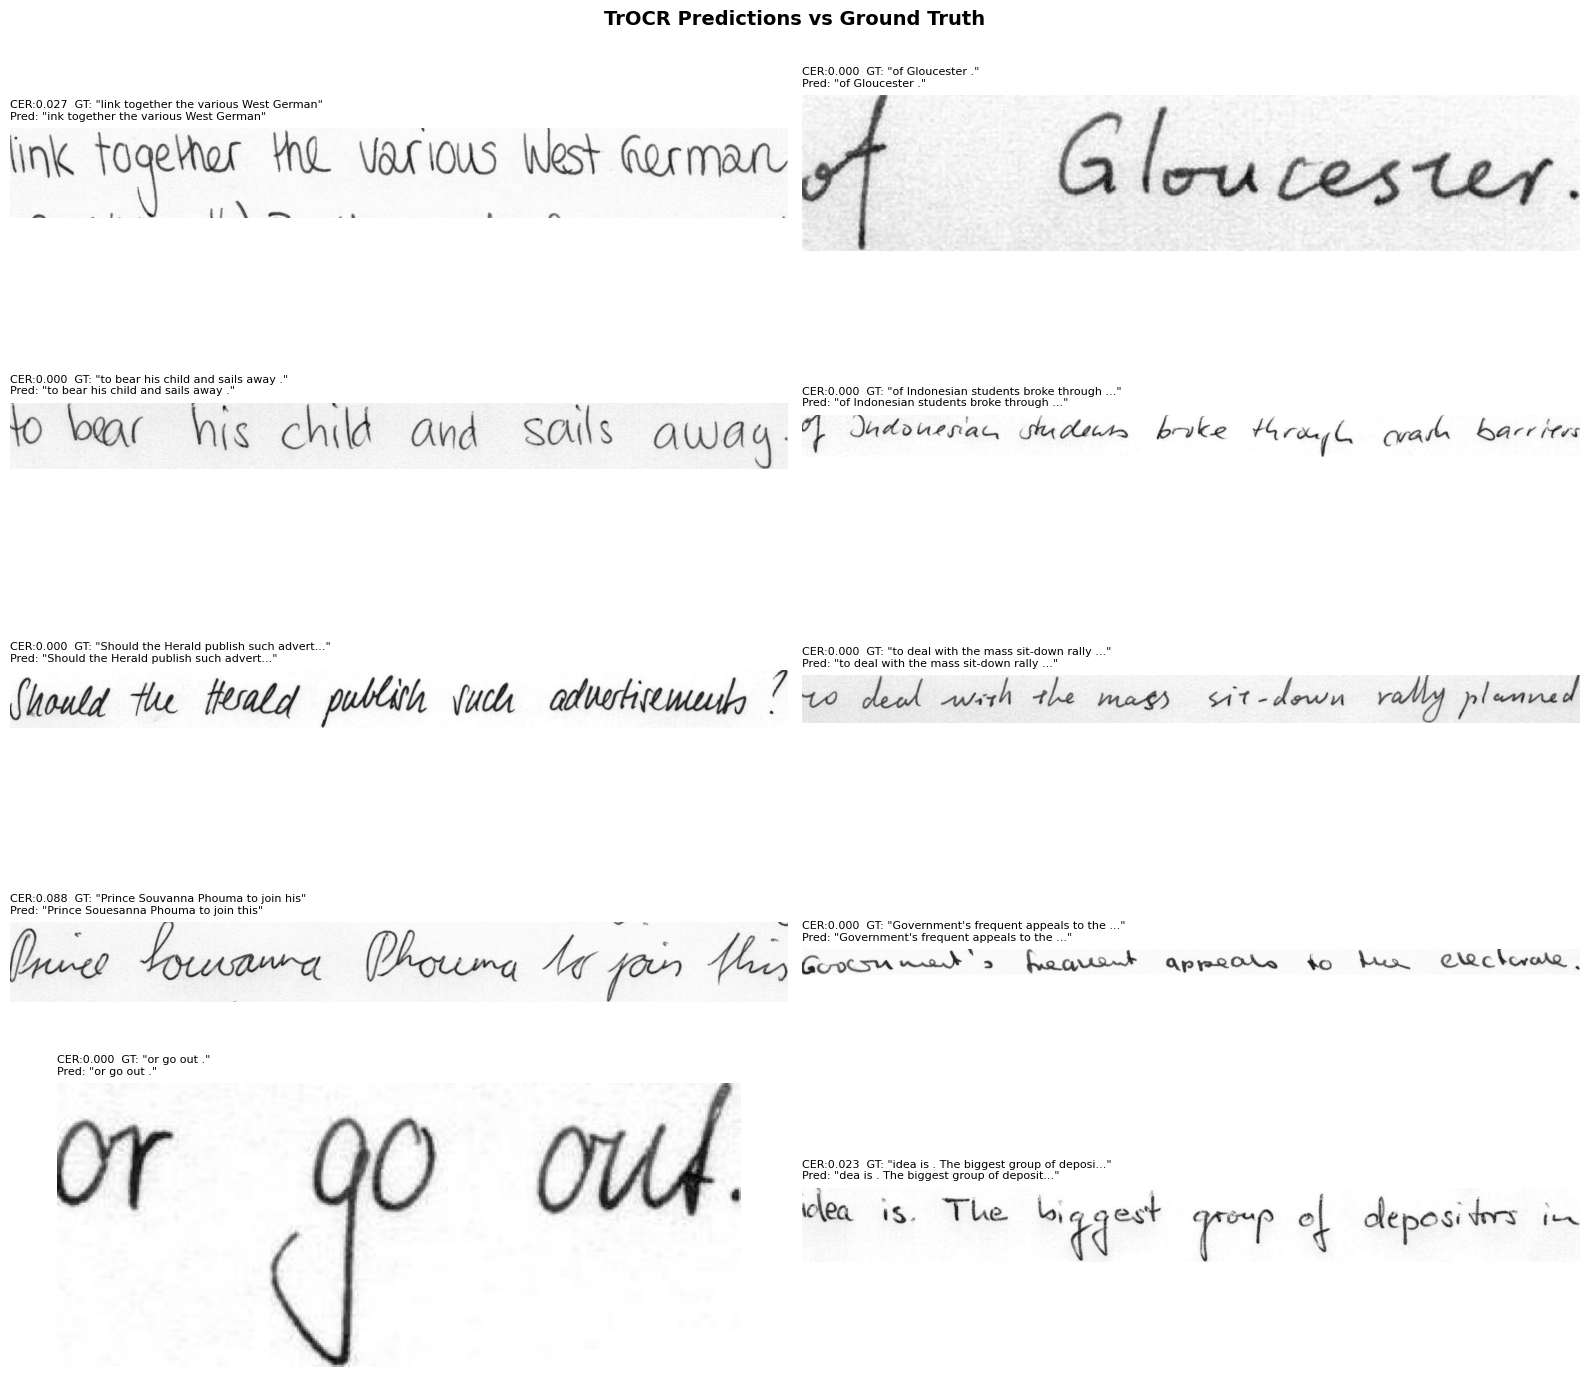

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
fig.suptitle('TrOCR Predictions vs Ground Truth', fontsize=14, fontweight='bold')
for idx in range(10):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    ax.imshow(test_data[idx]['image'], cmap='gray')
    gt_s = all_references[idx] if len(all_references[idx]) <= 40 else all_references[idx][:37] + '...'
    pr_s = all_predictions[idx] if len(all_predictions[idx]) <= 40 else all_predictions[idx][:37] + '...'
    ax.set_title(f'CER:{cer_full[idx]:.3f}  GT: "{gt_s}"\nPred: "{pr_s}"', fontsize=8, ha='left', x=0)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'predictions_vs_ground_truth.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Hybrid Similarity Scoring

In [12]:
from src.similarity import compute_hybrid_score

print('Computing similarity scores on 200 samples...')
sim_all = [compute_hybrid_score(p, r, return_breakdown=True) for p, r in zip(all_predictions, all_references)]
sim_initial = sim_all[:NUM_TEST_INITIAL]

df = pd.DataFrame({
    'reference': all_references, 'prediction': all_predictions,
    'cer': cer_full, 'wer': wer_full,
    'levenshtein': [s['levenshtein'] for s in sim_all],
    'bleu': [s['bleu'] for s in sim_all],
    'cosine': [s['cosine'] for s in sim_all],
    'combined': [s['combined_score'] for s in sim_all],
    'text_length': [len(r) for r in all_references],
})
df_initial = df.iloc[:NUM_TEST_INITIAL].copy()

print('\nSIMILARITY COMPARISON: INITIAL vs EXPANDED')
print('=' * 60)
print(f'{"Metric":<20} {"Initial (50)":>14} {"Expanded (200)":>14}')
print('-' * 60)
for col in ['levenshtein', 'bleu', 'cosine', 'combined']:
    print(f'{col:<20} {df_initial[col].mean():>14.4f} {df[col].mean():>14.4f}')

Computing similarity scores on 200 samples...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded sentence-transformers: all-MiniLM-L6-v2

SIMILARITY COMPARISON: INITIAL vs EXPANDED
Metric                 Initial (50) Expanded (200)
------------------------------------------------------------
levenshtein                  0.9931         0.9931
bleu                         0.9273         0.9403
cosine                       0.9778         0.9832
combined                     0.9680         0.9738


In [13]:
print('\nFULL SIMILARITY SUMMARY (200 samples)')
print('=' * 60)
print(df[['cer','wer','levenshtein','bleu','cosine','combined']].describe().round(4).to_string())


FULL SIMILARITY SUMMARY (200 samples)
            cer       wer  levenshtein      bleu    cosine  combined
count  200.0000  200.0000     200.0000  200.0000  200.0000  200.0000
mean     0.0070    0.0249       0.9931    0.9403    0.9832    0.9738
std      0.0211    0.0731       0.0207    0.1800    0.0644    0.0763
min      0.0000    0.0000       0.8919    0.1221    0.6151    0.6095
25%      0.0000    0.0000       1.0000    1.0000    1.0000    1.0000
50%      0.0000    0.0000       1.0000    1.0000    1.0000    1.0000
75%      0.0000    0.0000       1.0000    1.0000    1.0000    1.0000
max      0.1143    0.3529       1.0000    1.0000    1.0000    1.0000


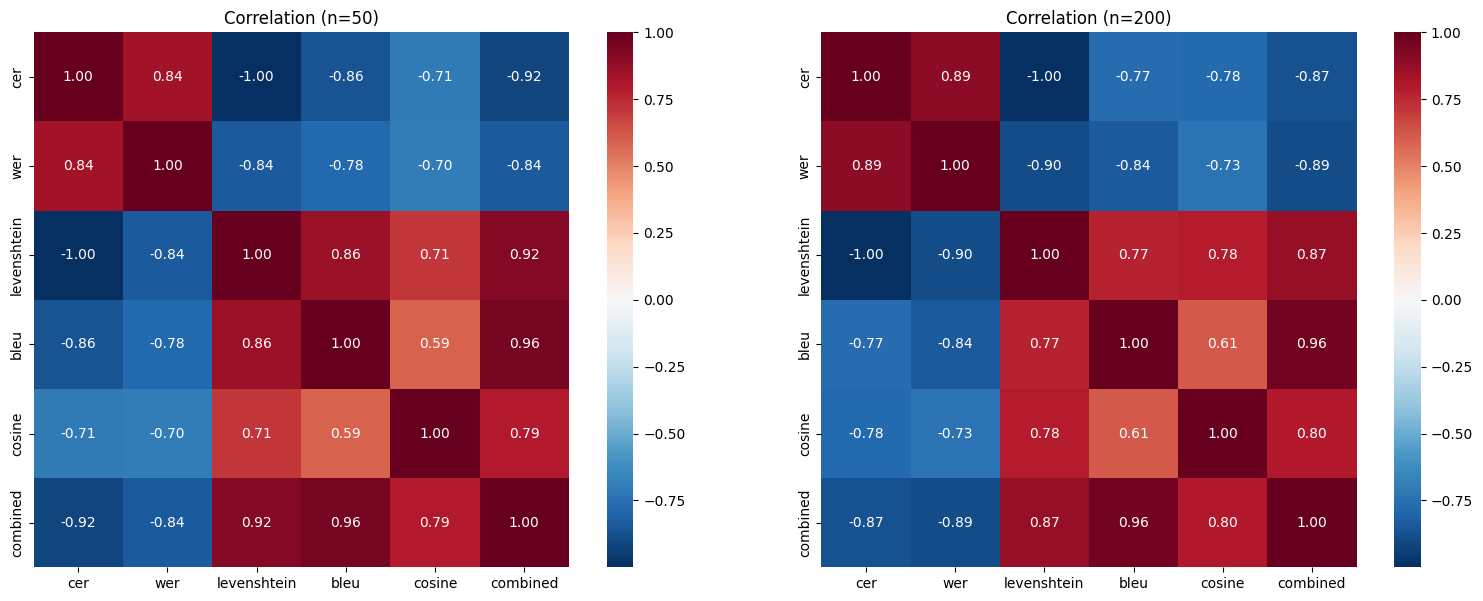

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr_init = df_initial[['cer','wer','levenshtein','bleu','cosine','combined']].corr()
sns.heatmap(corr_init, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[0], square=True)
axes[0].set_title(f'Correlation (n={NUM_TEST_INITIAL})')
corr_full = df[['cer','wer','levenshtein','bleu','cosine','combined']].corr()
sns.heatmap(corr_full, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1], square=True)
axes[1].set_title(f'Correlation (n={NUM_TEST_FULL})')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'correlation_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

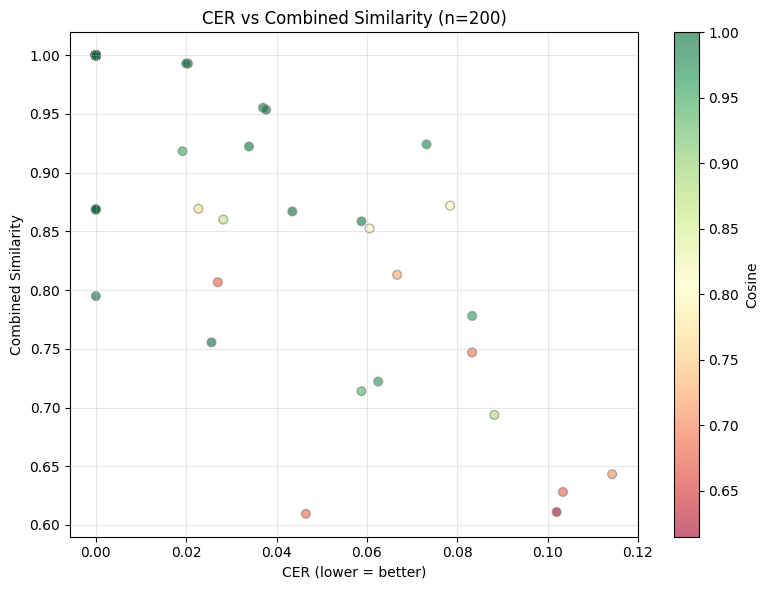

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df['cer'], df['combined'], c=df['cosine'], cmap='RdYlGn', alpha=0.6, edgecolors='gray', s=40)
ax.set_xlabel('CER (lower = better)'); ax.set_ylabel('Combined Similarity')
ax.set_title(f'CER vs Combined Similarity (n={NUM_TEST_FULL})'); plt.colorbar(sc, label='Cosine'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_vs_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cascade Failure Analysis

Stratify similarity scores by OCR quality to isolate transcription errors from content mismatches.

In [16]:
from src.evaluation import cascade_analysis

cascade_init = cascade_analysis(predictions_initial, references_initial, cer_threshold=0.1)
cascade_full = cascade_analysis(all_predictions, all_references, cer_threshold=0.1)

print('CASCADE ANALYSIS COMPARISON')
print('=' * 70)
print(f'{"":<25} {"Initial (50)":>20} {"Expanded (200)":>20}')
print('-' * 70)
print(f'{"Good OCR count":<25} {cascade_init["good_ocr"]["count"]:>20} {cascade_full["good_ocr"]["count"]:>20}')
print(f'{"Poor OCR count":<25} {cascade_init["poor_ocr"]["count"]:>20} {cascade_full["poor_ocr"]["count"]:>20}')

for label, key in [('Good OCR (CER <= 0.1)', 'good_ocr'), ('Poor OCR (CER > 0.1)', 'poor_ocr')]:
    g = cascade_full[key]
    if g['count'] > 0:
        print(f'\nExpanded — {label}: n={g["count"]}')
        print(f'  Mean CER: {g["mean_cer"]:.4f}, Combined: {g["mean_combined"]:.4f}')
        print(f'  Lev: {g["mean_levenshtein"]:.4f}, BLEU: {g["mean_bleu"]:.4f}, Cos: {g["mean_cosine"]:.4f}')

CASCADE ANALYSIS COMPARISON
                                  Initial (50)       Expanded (200)
----------------------------------------------------------------------
Good OCR count                              49                  197
Poor OCR count                               1                    3

Expanded — Good OCR (CER <= 0.1): n=197
  Mean CER: 0.0055, Combined: 0.9791
  Lev: 0.9946, BLEU: 0.9506, Cos: 0.9880

Expanded — Poor OCR (CER > 0.1): n=3
  Mean CER: 0.1066, Combined: 0.6274
  Lev: 0.8955, BLEU: 0.2669, Cos: 0.6685


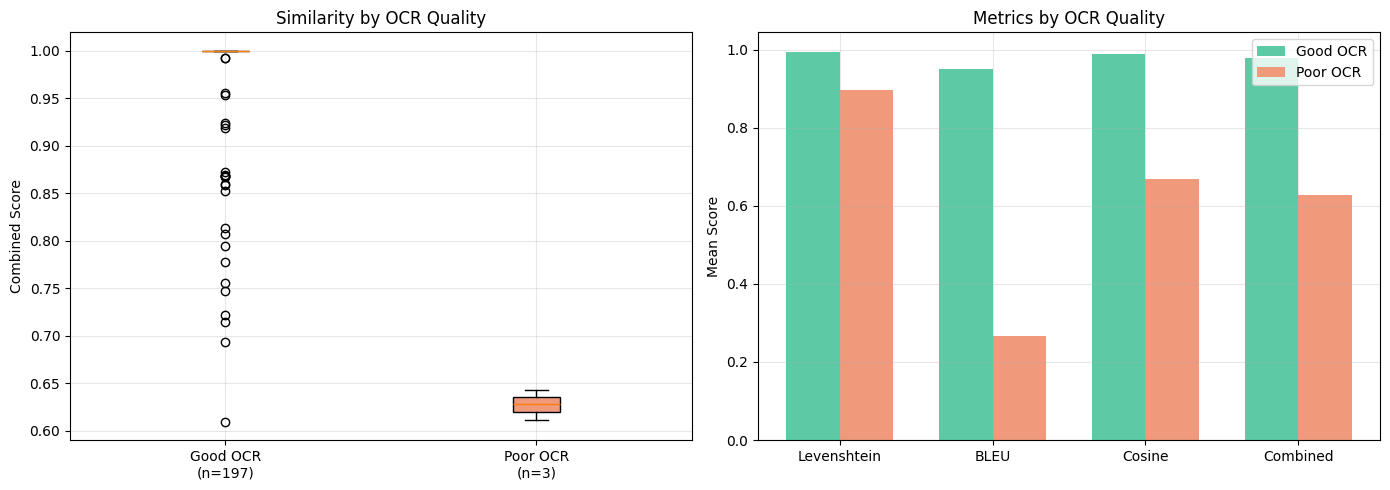

In [17]:
good_c = [s['combined_score'] for s in cascade_full['good_ocr_samples']]
poor_c = [s['combined_score'] for s in cascade_full['poor_ocr_samples']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data_box, labels_box = [], []
if good_c: data_box.append(good_c); labels_box.append(f'Good OCR\n(n={len(good_c)})')
if poor_c: data_box.append(poor_c); labels_box.append(f'Poor OCR\n(n={len(poor_c)})')
if data_box:
    bp = axes[0].boxplot(data_box, tick_labels=labels_box, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#5DCAA5','#F0997B']): patch.set_facecolor(c)
axes[0].set_ylabel('Combined Score'); axes[0].set_title('Similarity by OCR Quality'); axes[0].grid(alpha=0.3)

names = ['Levenshtein','BLEU','Cosine','Combined']
keys_ = ['mean_levenshtein','mean_bleu','mean_cosine','mean_combined']
x = np.arange(len(names)); w = 0.35
if cascade_full['good_ocr']['count'] > 0:
    axes[1].bar(x-w/2, [cascade_full['good_ocr'].get(k,0) or 0 for k in keys_], w, label='Good OCR', color='#5DCAA5')
if cascade_full['poor_ocr']['count'] > 0:
    axes[1].bar(x+w/2, [cascade_full['poor_ocr'].get(k,0) or 0 for k in keys_], w, label='Poor OCR', color='#F0997B')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel('Mean Score'); axes[1].set_title('Metrics by OCR Quality'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cascade_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Weight Sensitivity Analysis

How do different metric weight configurations affect the combined score?

In [18]:
weight_configs = [
    {'name': 'Equal',           'levenshtein': 0.33, 'bleu': 0.34, 'cosine': 0.33},
    {'name': 'Default',         'levenshtein': 0.35, 'bleu': 0.30, 'cosine': 0.35},
    {'name': 'Character-heavy', 'levenshtein': 0.60, 'bleu': 0.20, 'cosine': 0.20},
    {'name': 'Semantic-heavy',  'levenshtein': 0.20, 'bleu': 0.20, 'cosine': 0.60},
    {'name': 'BLEU-heavy',      'levenshtein': 0.20, 'bleu': 0.60, 'cosine': 0.20},
    {'name': 'Lev+Cos (no BLEU)', 'levenshtein': 0.50, 'bleu': 0.00, 'cosine': 0.50},
]

print('WEIGHT SENSITIVITY ANALYSIS')
print('=' * 70)
print(f'{"Config":<22} {"Weights (L/B/C)":<18} {"Mean":>8} {"Std":>8} {"Min":>8}')
print('-' * 70)

sensitivity_results = []
for cfg in weight_configs:
    w = {k: cfg[k] for k in ['levenshtein', 'bleu', 'cosine']}
    scores = [compute_hybrid_score(p, r, weights=w)['combined_score'] for p, r in zip(all_predictions, all_references)]
    sensitivity_results.append({'name': cfg['name'], 'mean': np.mean(scores), 'std': np.std(scores), 'min': np.min(scores)})
    w_str = f'{cfg["levenshtein"]:.2f}/{cfg["bleu"]:.2f}/{cfg["cosine"]:.2f}'
    print(f'{cfg["name"]:<22} {w_str:<18} {np.mean(scores):>8.4f} {np.std(scores):>8.4f} {np.min(scores):>8.4f}')

WEIGHT SENSITIVITY ANALYSIS
Config                 Weights (L/B/C)        Mean      Std      Min
----------------------------------------------------------------------
Equal                  0.33/0.34/0.33       0.9719   0.0817   0.5816
Default                0.35/0.30/0.35       0.9738   0.0761   0.6095
Character-heavy        0.60/0.20/0.20       0.9806   0.0557   0.7161
Semantic-heavy         0.20/0.20/0.60       0.9766   0.0705   0.6030
BLEU-heavy             0.20/0.60/0.20       0.9595   0.1194   0.4006
Lev+Cos (no BLEU)      0.50/0.00/0.50       0.9882   0.0407   0.7565


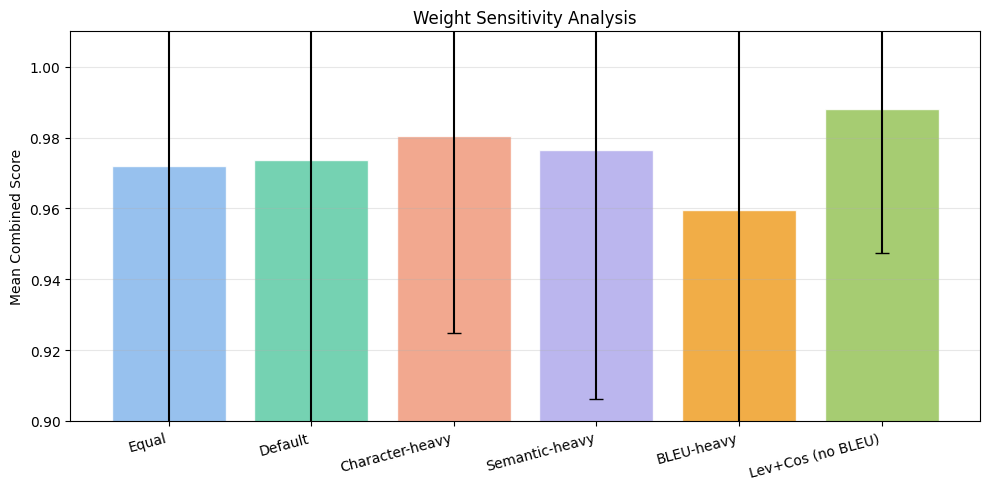

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
names = [r['name'] for r in sensitivity_results]
means = [r['mean'] for r in sensitivity_results]
stds = [r['std'] for r in sensitivity_results]
bars = ax.bar(names, means, yerr=stds, capsize=5, color=['#85B7EB','#5DCAA5','#F0997B','#AFA9EC','#EF9F27','#97C459'], edgecolor='white', alpha=0.85)
ax.set_ylabel('Mean Combined Score'); ax.set_title('Weight Sensitivity Analysis')
ax.set_ylim(0.9, 1.01); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'weight_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Difficulty-Stratified Evaluation

How does text length affect OCR performance and similarity scores?

PERFORMANCE BY TEXT LENGTH
                 count  mean_cer  mean_wer  mean_combined
length_bin                                               
Short (<20)          7    0.0173    0.0714         0.8526
Medium (20-40)      66    0.0098    0.0326         0.9641
Long (40-60)       116    0.0052    0.0184         0.9854
Very Long (60+)     11    0.0026    0.0182         0.9873


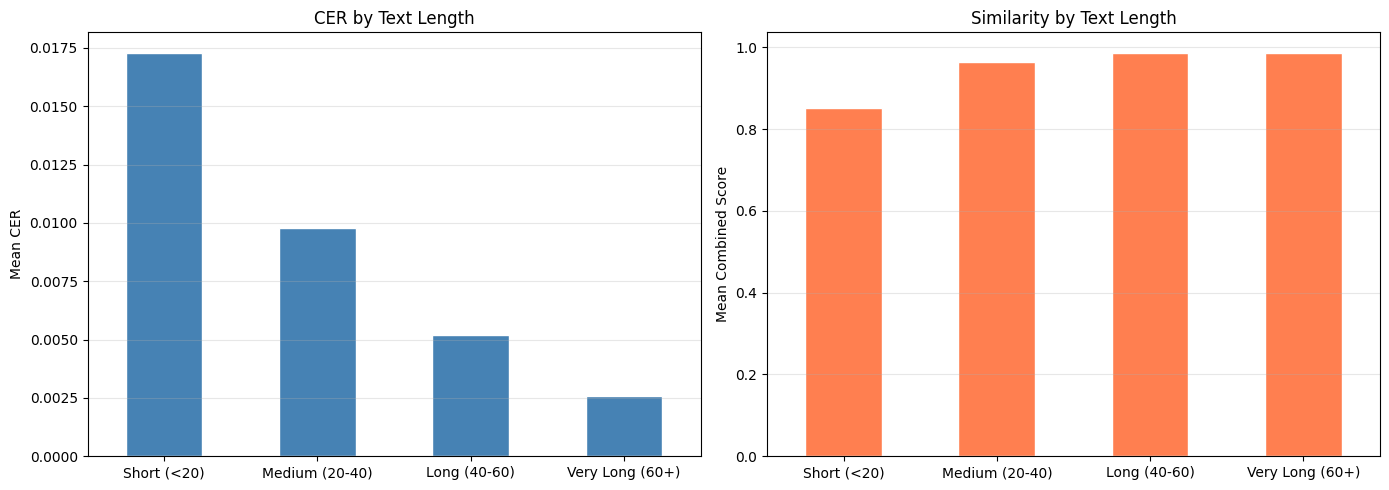

In [20]:
df['length_bin'] = pd.cut(df['text_length'], bins=[0, 20, 40, 60, 200], labels=['Short (<20)', 'Medium (20-40)', 'Long (40-60)', 'Very Long (60+)'])

print('PERFORMANCE BY TEXT LENGTH')
print('=' * 70)
grouped = df.groupby('length_bin', observed=True).agg(
    count=('cer', 'count'), mean_cer=('cer', 'mean'),
    mean_wer=('wer', 'mean'), mean_combined=('combined', 'mean'),
).round(4)
print(grouped.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grouped.plot(y='mean_cer', kind='bar', ax=axes[0], color='steelblue', edgecolor='white', legend=False)
axes[0].set_ylabel('Mean CER'); axes[0].set_title('CER by Text Length'); axes[0].set_xlabel(''); axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)
grouped.plot(y='mean_combined', kind='bar', ax=axes[1], color='coral', edgecolor='white', legend=False)
axes[1].set_ylabel('Mean Combined Score'); axes[1].set_title('Similarity by Text Length'); axes[1].set_xlabel(''); axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'difficulty_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Save All Results

In [21]:
final_results = {
    'model': MODEL_NAME,
    'device': device,
    'initial_evaluation': {
        'samples': NUM_TEST_INITIAL, 'mean_cer': ocr_initial['mean_cer'], 'mean_wer': ocr_initial['mean_wer'],
        'mean_combined': round(df_initial['combined'].mean(), 4),
    },
    'expanded_evaluation': {
        'samples': NUM_TEST_FULL, 'mean_cer': ocr_full['mean_cer'], 'mean_wer': ocr_full['mean_wer'],
        'mean_combined': round(df['combined'].mean(), 4),
        'mean_levenshtein': round(df['levenshtein'].mean(), 4),
        'mean_bleu': round(df['bleu'].mean(), 4),
        'mean_cosine': round(df['cosine'].mean(), 4),
    },
    'cascade': {
        'good_ocr_count': cascade_full['good_ocr']['count'],
        'poor_ocr_count': cascade_full['poor_ocr']['count'],
        'good_combined': cascade_full['good_ocr'].get('mean_combined'),
        'poor_combined': cascade_full['poor_ocr'].get('mean_combined'),
    },
}

with open(os.path.join(RESULTS_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
df.to_csv(os.path.join(RESULTS_DIR, 'test_results.csv'), index=False)

print('All results saved:')
for fname in sorted(os.listdir(RESULTS_DIR)):
    if not fname.startswith('.'): print(f'  {fname}')

All results saved:
  cascade_analysis.png
  cer_distributions.png
  cer_vs_similarity.png
  correlation_heatmaps.png
  difficulty_analysis.png
  final_results.json
  predictions_vs_ground_truth.png
  preprocessing_comparison.png
  sample_images.png
  test_results.csv
  text_length_distributions.png
  weight_sensitivity.png


---
## 10. Launch Gradio Interface

Also available via `python ui/app.py`.

In [22]:
import gradio as gr
from src.evaluation import compute_cer, compute_wer
from src.preprocessing import pil_to_cv2, cv2_to_pil, preprocess_image, assess_image_quality

def get_confidence(score):
    if score >= 0.90: return 'High Confidence'
    elif score >= 0.70: return 'Medium Confidence'
    elif score >= 0.50: return 'Low Confidence'
    else: return 'Very Low Confidence'

def evaluate(image, ref_text, wl, wb, wc):
    if image is None: return None, 'No image.', '', '', '', '', '', '', ''
    if not ref_text or not ref_text.strip(): return None, 'Enter reference text.', '', '', '', '', '', '', ''
    try:
        pil = Image.fromarray(image).convert('RGB') if isinstance(image, np.ndarray) else image.convert('RGB')
        cv2_img = pil_to_cv2(pil)
        quality = assess_image_quality(cv2_img)
        preprocessed = cv2_to_pil(preprocess_image(cv2_img))
        quality_str = f"Contrast: {quality['contrast']} | Sharpness: {quality['sharpness']} | Intensity: {quality['mean_intensity']}"
        pv = processor(images=pil, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            ids = model.generate(pv, max_length=128)
        transcription = processor.batch_decode(ids, skip_special_tokens=True)[0]
        s_cer = compute_cer(transcription, ref_text)
        s_wer = compute_wer(transcription, ref_text)
        tw = wl+wb+wc or 1.0
        sim = compute_hybrid_score(transcription, ref_text, weights={'levenshtein':wl/tw,'bleu':wb/tw,'cosine':wc/tw}, return_breakdown=True)
        conf = get_confidence(sim['combined_score'])
        return (preprocessed, transcription, f'{s_cer:.4f} ({s_cer*100:.2f}%)', f'{s_wer:.4f} ({s_wer*100:.2f}%)',
                f'{sim["levenshtein"]:.4f}', f'{sim["bleu"]:.4f}', f'{sim["cosine"]:.4f}', f'{sim["combined_score"]:.4f} — {conf}', quality_str)
    except Exception as e:
        return None, f'Error: {e}', '', '', '', '', '', '', ''

with gr.Blocks(title='ScribeCheck') as demo:
    gr.Markdown('# ScribeCheck — Handwritten Text Evaluation\nUpload a handwritten image and enter reference text. Features preprocessing preview and confidence scoring.')
    with gr.Row():
        with gr.Column():
            gr.Markdown('### Input')
            img_in = gr.Image(type='pil', label='Handwritten Image')
            ref_in = gr.Textbox(label='Reference Text', placeholder='Enter expected text...', lines=3)
            gr.Markdown('#### Weights')
            with gr.Row():
                wl=gr.Slider(0,1,value=0.35,step=0.05,label='Levenshtein')
                wb=gr.Slider(0,1,value=0.30,step=0.05,label='BLEU')
                wc=gr.Slider(0,1,value=0.35,step=0.05,label='Cosine')
            btn=gr.Button('Run Evaluation',variant='primary',size='lg')
        with gr.Column():
            gr.Markdown('### Results')
            pp_out=gr.Image(label='Preprocessed Image',type='pil')
            q_out=gr.Textbox(label='Image Quality',interactive=False)
            t_out=gr.Textbox(label='OCR Transcription',interactive=False)
            with gr.Row():
                cer_o=gr.Textbox(label='CER',interactive=False)
                wer_o=gr.Textbox(label='WER',interactive=False)
            gr.Markdown('#### Similarity')
            with gr.Row():
                l_o=gr.Textbox(label='Levenshtein',interactive=False)
                b_o=gr.Textbox(label='BLEU',interactive=False)
                c_o=gr.Textbox(label='Cosine',interactive=False)
            cb_o=gr.Textbox(label='Combined Score & Confidence',interactive=False)
    btn.click(fn=evaluate,inputs=[img_in,ref_in,wl,wb,wc],outputs=[pp_out,t_out,cer_o,wer_o,l_o,b_o,c_o,cb_o,q_out])
    gr.Markdown('---\n**Note:** Model trained on IAM Handwriting Database. Performance may vary on different handwriting styles.')

print('Launching ScribeCheck...')
demo.launch(inline=True, share=False)

Launching ScribeCheck...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Summary

This notebook ran the complete ScribeCheck pipeline:

| Step | Output |
|------|--------|
| Dataset | IAM loaded, explored with statistics and visualizations |
| Preprocessing | Basic vs enhanced comparison (Otsu vs CLAHE + Adaptive) |
| OCR | CER/WER on 50 and 200 samples, compared against 4.4% baseline |
| Similarity | Hybrid scoring with correlation analysis |
| Cascade | Stratified by OCR quality — BLEU drops 72%, cosine only 32% |
| Weight sensitivity | 6 configurations — BLEU noisiest, Lev+Cos most stable |
| Difficulty | Shorter texts have higher CER (denominator effect) |
| Results | All metrics and plots saved to results/ |
| Interface | Gradio with preprocessing preview and confidence labels |